<a href="https://colab.research.google.com/github/JalalMominAfridi/JalalMominAfridi/blob/main/Hospital_budet_variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Budget Variance Analysis

## Project Overview

This project analyzes hospital departmental spending against budgeted amounts for 2024.

The objective is to identify:
- Which hospital departments have the largest budget variances
- Which department-month combinations exceeded budget by more than 10%
- Overall spending patterns across the year
- Areas where management may need to investigate or improve budget control

The analysis uses **Python, pandas, NumPy, SQLite, and SQL**.

> **Note:** The dataset used in this project is synthetic and was created specifically for this portfolio analysis. It does not contain real patient, hospital, or financial data.

In [1]:
import pandas as pd
import numpy as np
import sqlite3

np.random.seed(7)
departments = ["Emergency", "Surgery", "Pediatrics", "Radiology", "Pharmacy", "Cardiology"]
months = pd.period_range("2024-01", "2024-12", freq="M").astype(str)

rows = []
for d in departments:
    base = np.random.randint(80, 200) * 1000
    for m in months:
        actual = round(base * np.random.normal(1.03, 0.10), 2)
        rows.append((d, m, base, actual))

df = pd.DataFrame(rows, columns=["department", "month", "budget", "actual"])

conn = sqlite3.connect("hospital.db")
df.to_sql("spending", conn, if_exists="replace", index=False)
df.head()

,department,month,budget,actual
0,Emergency,2024-01,127000,121664.17
1,Emergency,2024-02,127000,117034.70
2,Emergency,2024-03,127000,130338.83
3,Emergency,2024-04,127000,135883.18
4,Emergency,2024-05,127000,116923.29


## 1. Budget Variance by Department

The first analysis aggregates the monthly spending data by department.

For each department, we calculate:

- Total annual budget
- Total annual actual spending
- Absolute variance
- Variance percentage

A positive variance indicates that actual spending exceeded the allocated budget, while a negative variance indicates spending was below budget.

In [2]:
summary = pd.read_sql("""
SELECT department,
       SUM(budget) AS total_budget,
       SUM(actual) AS total_actual,
       SUM(actual) - SUM(budget) AS variance,
       ROUND((SUM(actual) - SUM(budget)) * 100.0 / SUM(budget), 1) AS variance_pct
FROM spending
GROUP BY department
ORDER BY variance_pct DESC
""", conn)
summary

,department,total_budget,total_actual,variance,variance_pct
0,Pharmacy,1212000,1283690.07,71690.07,5.9
1,Surgery,960000,987617.89,27617.89,2.9
2,Cardiology,1476000,1475833.24,-166.76,-0.0
3,Radiology,2160000,2151584.30,-8415.70,-0.4
4,Pediatrics,1824000,1814130.56,-9869.44,-0.5
5,Emergency,1524000,1515395.93,-8604.07,-0.6


### Key Finding

Pharmacy has the highest positive budget variance at approximately **5.9%**, meaning annual actual spending exceeded the allocated budget by approximately **€71,690**.

Surgery is the second-highest overspending department at approximately **2.9%** above budget.

The remaining departments are approximately at or slightly below their annual budgets.

This suggests that Pharmacy should be the first department investigated for potential cost drivers such as medication prices, purchasing patterns, inventory levels, or unexpected demand.

## 2. Department-Months Exceeding Budget by More Than 10%

Annual averages can sometimes hide short-term spending problems.

The following SQL query identifies individual department-month combinations where actual spending exceeded the monthly budget by more than 10%.

In [3]:
over = pd.read_sql("""
SELECT department, month, budget, actual,
       ROUND((actual - budget) * 100.0 / budget, 1) AS variance_pct
FROM spending
WHERE (actual - budget) * 100.0 / budget > 10
ORDER BY variance_pct DESC
""", conn)
over

,department,month,budget,actual,variance_pct
0,Radiology,2024-05,180000,217190.90,20.7
1,Pharmacy,2024-03,101000,121210.49,20.0
2,Cardiology,2024-05,123000,147248.04,19.7
3,Radiology,2024-04,180000,211715.56,17.6
4,Pharmacy,2024-05,101000,118691.46,17.5
5,Cardiology,2024-01,123000,141766.16,15.3
6,Pharmacy,2024-07,101000,115407.01,14.3
7,Pharmacy,2024-08,101000,112905.16,11.8
8,Surgery,2024-09,80000,89391.15,11.7
9,Radiology,2024-07,180000,200533.20,11.4


### Key Finding

There are **13 department-month combinations** where actual spending exceeded the monthly budget by more than 10%.

Pharmacy appears repeatedly among the higher-variance months, reinforcing the finding from the annual departmental analysis.

These monthly spikes are important because they may indicate temporary cost increases or recurring operational issues that are not immediately visible when looking only at annual totals.

## 3. Visualizing Budget Variance

Two visualizations are used to make the results easier to interpret:

1. Budget variance percentage by department
2. Monthly hospital-wide budget versus actual spending

<Axes: title={'center': 'Budget variance % by department'}, ylabel='department'>

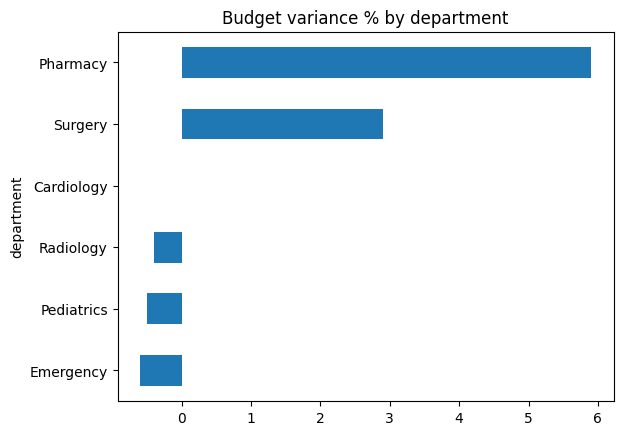

In [4]:
summary.sort_values("variance_pct").plot(x="department", y="variance_pct", kind="barh", title="Budget variance % by department", legend=False)

<Axes: title={'center': 'Budget vs actual by month'}, xlabel='month'>

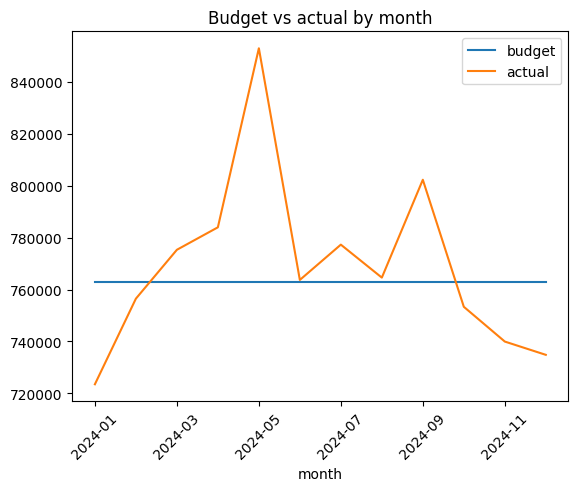

In [5]:
monthly = pd.read_sql("SELECT month, SUM(budget) AS budget, SUM(actual) AS actual FROM spending GROUP BY month ORDER BY month", conn)
monthly.plot(x="month", y=["budget", "actual"], title="Budget vs actual by month", rot=45)

## 4. Findings and Recommendations

### Findings

- **Pharmacy** had the highest annual budget variance, with actual spending approximately **5.9% above budget**.
- Pharmacy's annual overspending amounted to approximately **€71,690**.
- **Surgery** was the second-highest overspending department at approximately **2.9% above budget**.
- There were **13 department-month combinations** where spending exceeded the monthly budget by more than **10%**.
- Pharmacy appeared repeatedly among the months with significant overspending, suggesting that the department deserves further investigation.

### Recommendations

1. **Review Pharmacy spending first** to identify the main cost drivers.
2. Analyze medication purchasing patterns, supplier prices, and inventory levels.
3. Investigate the individual months with variance above 10% to determine whether the increases were temporary or recurring.
4. Consider introducing monthly budget monitoring and variance alerts for departments with repeated overspending.
5. Compare future spending against historical patterns to identify unusual increases earlier.

### Conclusion

The analysis demonstrates how SQL and Python can be used to transform departmental spending data into actionable financial insights. The main priority identified by this analysis is Pharmacy, which shows the largest annual positive variance and several months of significant overspending.

> **Data note:** This project uses a synthetic dataset created for portfolio and demonstration purposes. It does not represent actual hospital financial or patient data.